**Mini-Projeto 2 | Sistemas Baseados em Conhecimento — Caminho A (SBC novo)**  
**Controlador Fuzzy Mamdani** implementado em `scikit-fuzzy`

---

## Domínio

Um atleta deve treinar na intensidade certa: treinar muito forte com fadiga alta causa lesões;
treinar muito leve quando está descansado e bem condicionado desperdiça a sessão.
O **FuzzyFit** recebe duas variáveis linguísticas — **nível de condicionamento físico** e
**fadiga atual percebida** — e recomenda a **intensidade do treino em % da FCmáx**.

**Por que fuzzy?** Conceitos como _fadiga moderada_ ou _atleta intermediário_ não têm
fronteiras nítidas. Um sistema crisp diria: `cond > 7` -> avançado; `cond = 6.9` -> intermediário.
O fuzzy trata essa imprecisão linguística naturalmente, produzindo saída contínua e suave.

---

### Variáveis

| Variável | Tipo | Universo | Termos linguísticos |
|---|---|---|---|
| `nivel_condicionamento` | Antecedente | 0 – 10 | iniciante · intermediário · avançado |
| `fadiga_atual` | Antecedente | 0 – 10 (PSE) | baixa · moderada · alta |
| `intensidade_treino` | Consequente | 50 – 100 (% FCmáx) | leve · moderada · intensa |

---

### Base de Regras (9 regras — cobertura total 3×3)

| # | Condicionamento | Fadiga | → Intensidade |
|---|---|---|---|
| R1 | Iniciante | Baixa | Leve |
| R2 | Iniciante | Moderada | Leve |
| R3 | Iniciante | Alta | Leve |
| R4 | Intermediário | Baixa | Moderada |
| R5 | Intermediário | Moderada | Moderada |
| R6 | Intermediário | Alta | Leve |
| R7 | Avançado | Baixa | Intensa |
| R8 | Avançado | Moderada | Moderada |
| R9 | Avançado | Alta | Leve |

In [ ]:
# Instalar scikit-fuzzy (necessário no Google Colab)
!pip install scikit-fuzzy

## Imports

In [13]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Seção 1 — Antecedentes e Consequente

In [14]:
# Antecedente 1: Nível de Condicionamento Físico (0 = iniciante, 10 = elite)
nivel_condicionamento = ctrl.Antecedent(
    np.arange(0, 11, 1), 'nivel_condicionamento'
)

# Antecedente 2: Fadiga Atual — Percepção Subjetiva de Esforço (PSE 0–10)
# 0 = sem fadiga / 10 = exaustão máxima
fadiga_atual = ctrl.Antecedent(
    np.arange(0, 11, 1), 'fadiga_atual'
)

# Consequente: Intensidade do Treino Recomendada (% FCmáx, universo 50–100)
intensidade_treino = ctrl.Consequent(
    np.arange(50, 101, 1), 'intensidade_treino'
)


## Seção 2 — Funções de Pertinência

- **`trapmf`** (trapezoidal): usada nos extremos, onde o conceito é pleno em toda uma faixa.
- **`trimf`** (triangular): usada nos termos do meio, com pico bem definido.


In [15]:
# Nível de Condicionamento (0–10)
nivel_condicionamento['iniciante']     = fuzz.trapmf(
    nivel_condicionamento.universe, [0, 0, 2, 4]
)
nivel_condicionamento['intermediario'] = fuzz.trimf(
    nivel_condicionamento.universe, [2, 5, 8]
)
nivel_condicionamento['avancado']      = fuzz.trapmf(
    nivel_condicionamento.universe, [6, 8, 10, 10]
)

# Fadiga Atual - PSE (0–10)
fadiga_atual['baixa']    = fuzz.trapmf(
    fadiga_atual.universe, [0, 0, 2, 4]
)
fadiga_atual['moderada'] = fuzz.trimf(
    fadiga_atual.universe, [2, 5, 8]
)
fadiga_atual['alta']     = fuzz.trapmf(
    fadiga_atual.universe, [6, 8, 10, 10]
)

# Intensidade do Treino (% FCmáx, universo 50–100)
# Leve    : 50–68%  (zona aeróbica leve / recuperação ativa)
# Moderada: 62–86%  (zona aeróbica / limiar anaeróbico)
# Intensa : 80–100% (zona anaeróbica / VO2 máximo)
intensidade_treino['leve']     = fuzz.trapmf(
    intensidade_treino.universe, [50, 50, 58, 68]
)
intensidade_treino['moderada'] = fuzz.trimf(
    intensidade_treino.universe, [62, 74, 86]
)
intensidade_treino['intensa']  = fuzz.trapmf(
    intensidade_treino.universe, [80, 90, 100, 100]
)

## Seção 3 — Visualização das Funções de Pertinência

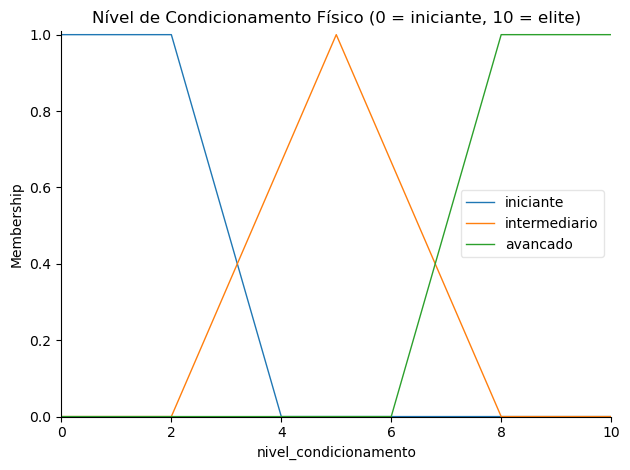

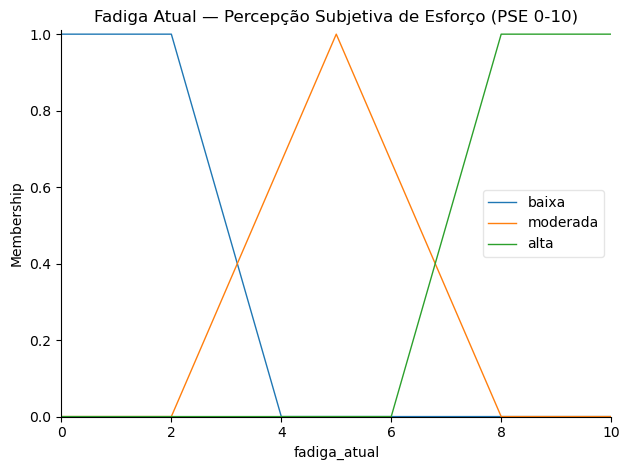

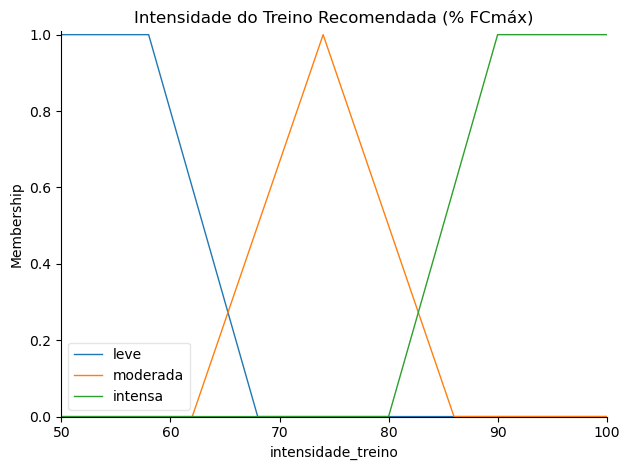

In [16]:
nivel_condicionamento.view()
plt.title('Nível de Condicionamento Físico (0 = iniciante, 10 = elite)')
plt.tight_layout()
plt.show()

fadiga_atual.view()
plt.title('Fadiga Atual — Percepção Subjetiva de Esforço (PSE 0-10)')
plt.tight_layout()
plt.show()

intensidade_treino.view()
plt.title('Intensidade do Treino Recomendada (% FCmáx)')
plt.tight_layout()
plt.show()

## Seção 4 — Base de Regras Fuzzy

```
Matriz de decisão (condicionamento x fadiga):

              fadiga: BAIXA   MODERADA   ALTA
INICIANTE    ->  LEVE    LEVE       LEVE
INTERMEDIARIO->  MOD.    MOD.       LEVE
AVANCADO     ->  INT.    MOD.       LEVE
```


In [ ]:
r1 = ctrl.Rule(nivel_condicionamento['iniciante']     & fadiga_atual['baixa'],    intensidade_treino['leve'])
r2 = ctrl.Rule(nivel_condicionamento['iniciante']     & fadiga_atual['moderada'], intensidade_treino['leve'])
r3 = ctrl.Rule(nivel_condicionamento['iniciante']     & fadiga_atual['alta'],     intensidade_treino['leve'])
r4 = ctrl.Rule(nivel_condicionamento['intermediario'] & fadiga_atual['baixa'],    intensidade_treino['moderada'])
r5 = ctrl.Rule(nivel_condicionamento['intermediario'] & fadiga_atual['moderada'], intensidade_treino['moderada'])
r6 = ctrl.Rule(nivel_condicionamento['intermediario'] & fadiga_atual['alta'],     intensidade_treino['leve'])
r7 = ctrl.Rule(nivel_condicionamento['avancado']      & fadiga_atual['baixa'],    intensidade_treino['intensa'])
r8 = ctrl.Rule(nivel_condicionamento['avancado']      & fadiga_atual['moderada'], intensidade_treino['moderada'])
r9 = ctrl.Rule(nivel_condicionamento['avancado']      & fadiga_atual['alta'],     intensidade_treino['leve'])

## Seção 5 — Sistema de Controle e Simulação

In [18]:
sistema_fuzzy = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9])
simulacao     = ctrl.ControlSystemSimulation(sistema_fuzzy)

## Seção 6 — Casos de Teste

| Teste | Condicionamento | Fadiga | Saída esperada |
|---|---|---|---|
| A | 9.0 (avancado) | 1.5 (baixa) | Intensa (~90-95% FCmax) |
| B | 5.0 (intermediario) | 5.0 (moderada) | Moderada (~72-76% FCmax) |
| C | 3.5 (iniciante) | 7.5 (alta) | Leve (~54-60% FCmax) |


  RESULTADOS DOS CASOS DE TESTE

  Teste A: Atleta avancado, baixa fadiga - treino intenso
  Entradas -> condicionamento=9.0, fadiga=1.5
  Saida    -> 92.2% da FCmax
  Zona     -> Zona 5:   Anaerobico / VO2 Maximo


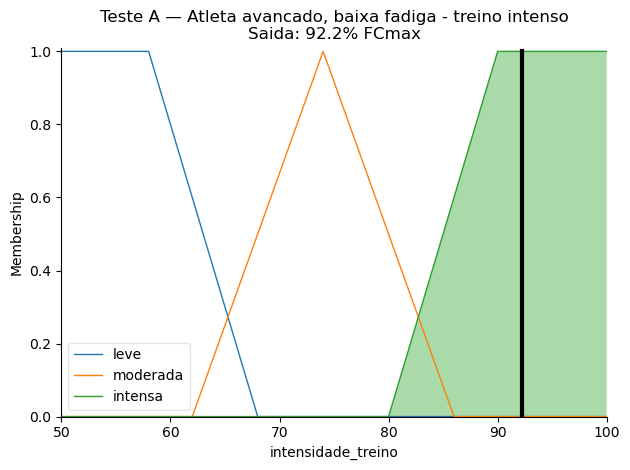


  Teste B: Atleta intermediario, fadiga moderada - manutencao
  Entradas -> condicionamento=5.0, fadiga=5.0
  Saida    -> 74.0% da FCmax
  Zona     -> Zona 3-4: Aerobico Moderado / Limiar Anaerobico


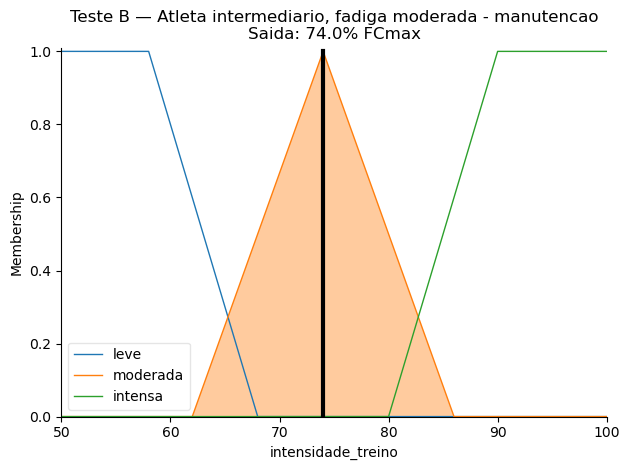


  Teste C: Iniciante, alta fadiga - recuperacao ativa
  Entradas -> condicionamento=3.5, fadiga=7.5
  Saida    -> 62.9% da FCmax
  Zona     -> Zona 1-2: Recuperacao / Aerobico Leve


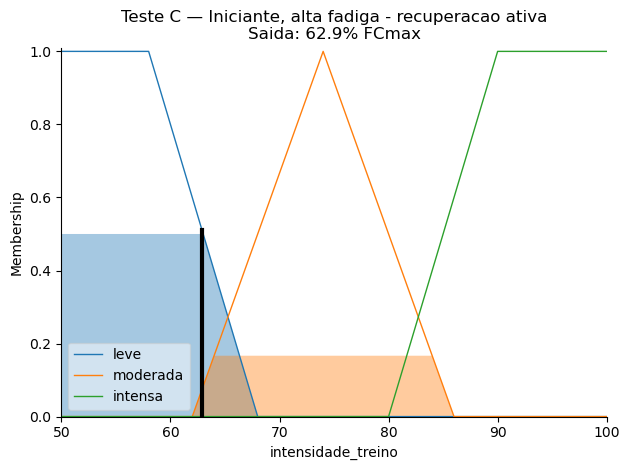

In [20]:
casos = [
    {'id': 'A', 'desc': 'Atleta avancado, baixa fadiga - treino intenso',     'cond': 9.0, 'fadiga': 1.5},
    {'id': 'B', 'desc': 'Atleta intermediario, fadiga moderada - manutencao', 'cond': 5.0, 'fadiga': 5.0},
    {'id': 'C', 'desc': 'Iniciante, alta fadiga - recuperacao ativa',          'cond': 3.5, 'fadiga': 7.5},
]

print('=' * 65)
print('  RESULTADOS DOS CASOS DE TESTE')
print('=' * 65)

for caso in casos:
    simulacao.input['nivel_condicionamento'] = caso['cond']
    simulacao.input['fadiga_atual']           = caso['fadiga']
    simulacao.compute()
    resultado = simulacao.output['intensidade_treino']

    print(f"\n  Teste {caso['id']}: {caso['desc']}")
    print(f"  Entradas -> condicionamento={caso['cond']}, fadiga={caso['fadiga']}")
    print(f"  Saida    -> {resultado:.1f}% da FCmax")

    if resultado < 68:
        zona = 'Zona 1-2: Recuperacao / Aerobico Leve'
    elif resultado < 84:
        zona = 'Zona 3-4: Aerobico Moderado / Limiar Anaerobico'
    else:
        zona = 'Zona 5:   Anaerobico / VO2 Maximo'
    print(f'  Zona     -> {zona}')

    intensidade_treino.view(sim=simulacao)
    plt.title(f"Teste {caso['id']} — {caso['desc']}\nSaida: {resultado:.1f}% FCmax")
    plt.tight_layout()
    plt.show()

print('\n' + '=' * 65)

## Seção 7 — Graus de Ativação das Regras (Teste C)

In [11]:
# Roda o Teste C para exibir os graus de ativação
simulacao.input['nivel_condicionamento'] = 3.5
simulacao.input['fadiga_atual']           = 7.5
simulacao.compute()

print('Graus de ativacao das regras (Teste C: iniciante + alta fadiga):')
for i, rule in enumerate(sistema_fuzzy.rules):
    activation = rule.aggregate_firing[simulacao]
    print(f'  Regra {i+1}: {rule}')
    print(f'            AND aggregation function : fmin')
    print(f'            OR  aggregation function : fmax -> Ativacao: {activation:.4f}')

Graus de ativacao das regras (Teste C: iniciante + alta fadiga):
  Regra 1: IF nivel_condicionamento[iniciante] AND fadiga_atual[baixa] THEN intensidade_treino[leve]
	AND aggregation function : fmin
	OR aggregation function  : fmax
            AND aggregation function : fmin
            OR  aggregation function : fmax -> Ativacao: 0.0000
  Regra 2: IF nivel_condicionamento[iniciante] AND fadiga_atual[moderada] THEN intensidade_treino[leve]
	AND aggregation function : fmin
	OR aggregation function  : fmax
            AND aggregation function : fmin
            OR  aggregation function : fmax -> Ativacao: 0.1667
  Regra 3: IF nivel_condicionamento[iniciante] AND fadiga_atual[alta] THEN intensidade_treino[leve]
	AND aggregation function : fmin
	OR aggregation function  : fmax
            AND aggregation function : fmin
            OR  aggregation function : fmax -> Ativacao: 0.2500
  Regra 4: IF nivel_condicionamento[intermediario] AND fadiga_atual[baixa] THEN intensidade_treino[moderada]

## Seção 8 — Superfície de Decisão

A superfície mostra como a saída varia **continuamente** no espaço das entradas — sem saltos abruptos.
Essa suavidade é a principal vantagem do controlador fuzzy sobre o `if-elif` crisp.


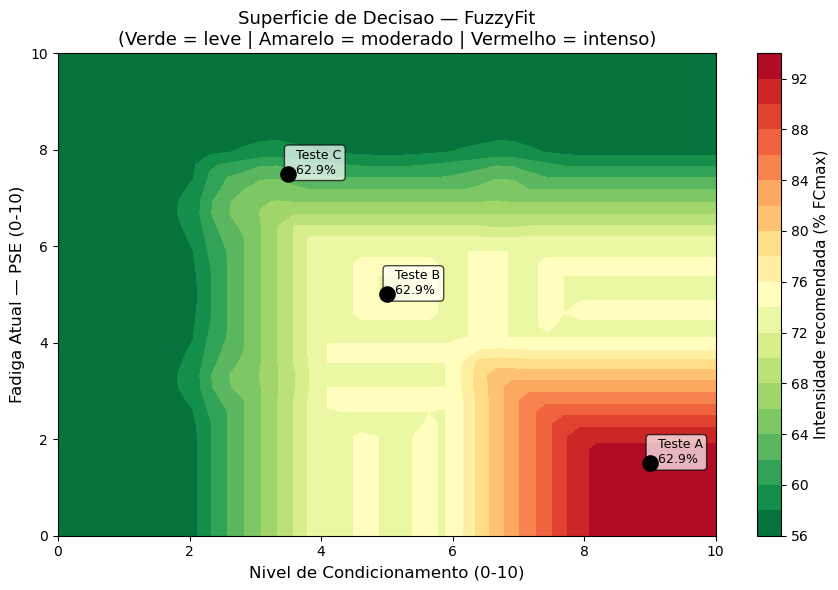

In [21]:
x_cond   = np.linspace(0, 10, 40)
x_fadiga = np.linspace(0, 10, 40)
Z = np.zeros((len(x_fadiga), len(x_cond)))

sim_surf = ctrl.ControlSystemSimulation(sistema_fuzzy)

for i, f in enumerate(x_fadiga):
    for j, c in enumerate(x_cond):
        try:
            sim_surf.input['nivel_condicionamento'] = c
            sim_surf.input['fadiga_atual']           = f
            sim_surf.compute()
            Z[i, j] = sim_surf.output['intensidade_treino']
        except Exception:
            Z[i, j] = float('nan')

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(x_cond, x_fadiga, Z, levels=20, cmap='RdYlGn_r')
cb = fig.colorbar(cf, ax=ax)
cb.set_label('Intensidade recomendada (% FCmax)', fontsize=11)
ax.set_xlabel('Nivel de Condicionamento (0-10)', fontsize=12)
ax.set_ylabel('Fadiga Atual — PSE (0-10)', fontsize=12)
ax.set_title('Superficie de Decisao — FuzzyFit\n'
             '(Verde = leve | Amarelo = moderado | Vermelho = intenso)',
             fontsize=13)

# Marcar os 3 casos de teste na superficie
for caso in casos:
    simulacao.input['nivel_condicionamento'] = caso['cond']
    simulacao.input['fadiga_atual']           = caso['fadiga']
    simulacao.compute()
    z_val = simulacao.output['intensidade_treino']
    ax.scatter(caso['cond'], caso['fadiga'], s=120, color='black', zorder=5)
    ax.annotate(
        f"  Teste {caso['id']}\n  {z_val:.1f}%",
        xy=(caso['cond'], caso['fadiga']),
        fontsize=9, color='black',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
    )

plt.tight_layout()
plt.show()